# MORPH-Guard CRC — ResNet18 Multi-Rate Evaluation on NCT-CRC (Seed 42)

**Goal:** evaluate the same ResNet18 under three supervision conditions on the **NCT-CRC** colorectal histology dataset:

1. **Clean training** — original clean labels.
2. **MABP-poisoned training** — unchanged MABP-V3 at **20%, 30%, 40%, and 50%**.
3. **MABP + MORPH-Guard training** — unchanged MORPH-Guard V3 diagnostics/repair, followed by the same ResNet18 trained on repaired soft targets and sample weights.

### Fairness controls for the main journal experiment
- Seed = **42**.
- One fixed 70/15/15 clean split.
- Same ResNet18 architecture, augmentation, optimizer, epoch budget, early stopping, validation set, and test set for clean, poisoned, and repaired training.
- Only the final training supervision changes.
- MABP attack formulas remain unchanged.
- MORPH-Guard `qT → qM → DynaFuse → continuous repair` formulas remain unchanged.
- One Excel workbook is produced with overall metrics, class-wise classification reports, confusion matrices, attack mappings, detection metrics, and repair diagnostics.

### Dataset
Local dataset path: `/content/dataset`

Expected classes (fixed order):
`ADI`, `BACK`, `DEB`, `LYM`, `MUC`, `MUS`, `NORM`, `STR`, `TUM`.


In [1]:
# 1. Install required packages (Colab/Kaggle friendly).
import sys, subprocess, importlib.util

required = {
    "timm": "timm",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "xlsxwriter": "XlsxWriter",
}

for module_name, pip_name in required.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

print("Dependencies ready.")

Dependencies ready.


In [2]:
# 2. Imports + strict reproducibility.
import os, json, math, random, shutil, time, copy, warnings, gc, subprocess
from pathlib import Path
from collections import Counter
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import timm
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print("Seed:", SEED)
print("Device:", DEVICE)
print("timm:", timm.__version__)

Seed: 42
Device: cuda
timm: 1.0.29


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import glob as gb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from zipfile import ZipFile
import cv2

In [4]:
from google.colab import files
files.upload()

Saving kaggle (16).json to kaggle (16).json


{'kaggle (16).json': b'{"username":"neazmulmowla","key":"d6054591002651c019a322a4926b498d"}'}

In [5]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = [("username", "neazmulmowla"), ("key", "d6054591002651c019a322a4926b498d")]
api_token_dict = dict(api_token)

import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token_dict, file)

!chmod 600 ~/.kaggle/kaggle.json

print('complete')

complete


In [6]:
!kaggle datasets download -d neazmulmowla/15k-per-class-nctcrc

Dataset URL: https://www.kaggle.com/datasets/neazmulmowla/15k-per-class-nctcrc
License(s): unknown
100% 348M/348M [00:03<00:00, 119MB/s]



In [7]:
from zipfile import ZipFile
file_name = '/content/15k-per-class-nctcrc.zip'

with ZipFile(file_name, 'r') as zip_file_obj:
  zip_file_obj.extractall()
  print('complete')

complete


## Dataset access — NCT-CRC

The dataset is expected to already exist at:

`/content/dataset`

No Kaggle download or authentication is used in this notebook.


In [8]:
# 3. NCT-CRC local dataset path.
# Dataset-only change: all attack, defense, training, and evaluation settings remain unchanged.
EXPECTED_CLASSES = [
    "ADI",
    "BACK",
    "DEB",
    "LYM",
    "MUC",
    "MUS",
    "NORM",
    "STR",
    "TUM",
]

DATASET_ROOT = Path("/content/dataset")

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f"NCT-CRC dataset directory was not found: {DATASET_ROOT}. "
        "Please place/extract the dataset at exactly this path before running the notebook."
    )

print("Dataset root:", DATASET_ROOT)


Dataset root: /content/dataset


In [9]:
# 4. Validate the fixed NCT-CRC class folders.
missing_classes = [
    c for c in EXPECTED_CLASSES
    if not (DATASET_ROOT / c).is_dir()
]

if missing_classes:
    raise FileNotFoundError(
        f"Missing expected class folders under {DATASET_ROOT}: {missing_classes}"
    )

print("NCT-CRC dataset found.")
print("Classes:", EXPECTED_CLASSES)


NCT-CRC dataset found.
Classes: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']


In [10]:
# 5. Configuration.
WORKDIR = Path("/content/morph_guard_nctcrc_resnet18_multirate_seed42")
WORKDIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 9
SAFE_DATALOADER = True
NUM_WORKERS = 0 if SAFE_DATALOADER else min(2, os.cpu_count() or 2)

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Multi-rate experiment.
POISON_RATES = [0.20, 0.30, 0.40, 0.50]

# ---------------- MABP-V3 attack: unchanged ----------------
ATTACK_TEMPERATURE = 0.10
ATTACK_ENTROPY_WEIGHT = 0.30
ATTACK_MARGIN_WEIGHT = 1.00
ATTACK_BACKBONE = "convnextv2_tiny.fcmae_ft_in22k_in1k"

# ------------ MORPH-Guard diagnostics: unchanged ----------
TARGET_BACKBONE = "convnextv2_atto.fcmae_ft_in1k"
EMBED_DIM = 256
HEAD_DROPOUT = 0.20
DROP_PATH_RATE = 0.10

# ---------------- Final downstream classifier -------------
FINAL_CLASSIFIER = "ResNet18"
RESNET18_DROPOUT = 0.20
RESNET18_FREEZE_EPOCHS = 1

# Fair comparison: identical final training budget in all conditions.
FINAL_EPOCHS = 20
PATIENCE = 6
BACKBONE_LR = 8e-5
HEAD_LR = 4e-4
WEIGHT_DECAY = 5e-4
GRAD_CLIP_NORM = 1.0

# ---------------- Cross-fit qT: unchanged -----------------
CROSSFIT_FOLDS = 2
CROSSFIT_EPOCHS = 6
WARMUP_LABEL_SMOOTHING = 0.03
EMA_WARMUP_DECAY = 0.995

# ---------------- Morphology qM: unchanged ----------------
KNN_K = 31
TRUSTED_CORE_FRAC = 0.45

# ---------------- DynaFuse: unchanged ---------------------
DYNAMIC_GATE_TEMPERATURE = 0.35
MIN_TEMPORAL_GATE = 0.15
MAX_TEMPORAL_GATE = 0.90

# ---------------- Continuous repair: unchanged ------------
REPAIR_Q_LOW = 0.20
REPAIR_Q_HIGH = 0.80
MAX_REPAIR_STRENGTH = 0.96
HARD_REPAIR_Q = 0.72
HARD_REPAIR_MARGIN = 0.08
HARD_REPAIR_ALT_PROB = 0.40
HARD_REPAIR_MIN_VOTES = 2
MIN_SAMPLE_WEIGHT = 0.35

RUN_LATENCY_BENCHMARK = True

print({
    "dataset": "NCT-CRC",
    "dataset_root": str(DATASET_ROOT),
    "classes": EXPECTED_CLASSES,
    "seed": SEED,
    "poison_rates": POISON_RATES,
    "attack_backbone": ATTACK_BACKBONE,
    "diagnostic_backbone": TARGET_BACKBONE,
    "final_classifier": FINAL_CLASSIFIER,
    "final_epochs_all_conditions": FINAL_EPOCHS,
})

{'dataset': 'NCT-CRC', 'dataset_root': '/content/dataset', 'classes': ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM'], 'seed': 42, 'poison_rates': [0.2, 0.3, 0.4, 0.5], 'attack_backbone': 'convnextv2_tiny.fcmae_ft_in22k_in1k', 'diagnostic_backbone': 'convnextv2_atto.fcmae_ft_in1k', 'final_classifier': 'ResNet18', 'final_epochs_all_conditions': 20}


In [11]:
# 6. Index NCT-CRC images and create ONE clean split BEFORE any attack.
VALID_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

# Fixed NCT-CRC class order.
classes = list(EXPECTED_CLASSES)
missing_classes = [c for c in classes if not (DATASET_ROOT / c).is_dir()]
if missing_classes:
    raise ValueError(
        f"Missing expected NCT-CRC class folders under {DATASET_ROOT}: {missing_classes}"
    )

if len(classes) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} classes, got {len(classes)}: {classes}")

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

image_paths, labels = [], []
class_counts = {}
for c in classes:
    files_in_class = sorted([
        p for p in (DATASET_ROOT / c).iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXT
    ])
    if not files_in_class:
        raise RuntimeError(f"No image files found in class folder: {DATASET_ROOT / c}")
    class_counts[c] = len(files_in_class)
    image_paths.extend(map(str, files_in_class))
    labels.extend([class_to_idx[c]] * len(files_in_class))

image_paths = np.asarray(image_paths)
labels = np.asarray(labels, dtype=np.int64)

if len(image_paths) == 0:
    raise RuntimeError("No NCT-CRC image files found.")

train_paths, tmp_paths, clean_train_labels, tmp_labels = train_test_split(
    image_paths,
    labels,
    test_size=VAL_FRAC + TEST_FRAC,
    random_state=SEED,
    stratify=labels,
)

test_relative = TEST_FRAC / (VAL_FRAC + TEST_FRAC)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths,
    tmp_labels,
    test_size=test_relative,
    random_state=SEED,
    stratify=tmp_labels,
)

train_paths = np.asarray(train_paths)
val_paths = np.asarray(val_paths)
test_paths = np.asarray(test_paths)
clean_train_labels = np.asarray(clean_train_labels, dtype=np.int64)
val_labels = np.asarray(val_labels, dtype=np.int64)
test_labels = np.asarray(test_labels, dtype=np.int64)

assert not np.any(np.isin(val_paths, train_paths))
assert not np.any(np.isin(test_paths, train_paths))
assert not np.any(np.isin(test_paths, val_paths))

print("Classes:", classes)
print("Images per class:", class_counts)
print(f"Total={len(labels):,} | Train={len(train_paths):,} | Val={len(val_paths):,} | Test={len(test_paths):,}")
print("Train distribution:", Counter(clean_train_labels.tolist()))

np.savez_compressed(
    WORKDIR / "nctcrc_clean_split_seed42.npz",
    train_paths=train_paths,
    clean_train_labels=clean_train_labels,
    val_paths=val_paths,
    val_labels=val_labels,
    test_paths=test_paths,
    test_labels=test_labels,
)


Classes: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Images per class: {'ADI': 1500, 'BACK': 1500, 'DEB': 1500, 'LYM': 1500, 'MUC': 1500, 'MUS': 1500, 'NORM': 1500, 'STR': 1500, 'TUM': 1500}
Total=13,500 | Train=9,450 | Val=2,025 | Test=2,025
Train distribution: Counter({0: 1050, 7: 1050, 1: 1050, 3: 1050, 8: 1050, 5: 1050, 2: 1050, 6: 1050, 4: 1050})


In [12]:
# 7. ONE common final-training augmentation pipeline.
# Clean, poisoned, and repaired ResNet18 all use this exact transform.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=180),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
            saturation=0.08,
            hue=0.02,
        )
    ], p=0.50),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class IndexedImageDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = np.asarray(paths)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as im:
            x = self.transform(im.convert("RGB"))
        return x, int(self.labels[idx]), int(idx)


class RepairedSoftTargetDataset(Dataset):
    def __init__(self, paths, soft_targets, sample_weights, transform):
        self.paths = np.asarray(paths)
        self.soft_targets = np.asarray(soft_targets, dtype=np.float32)
        self.sample_weights = np.asarray(sample_weights, dtype=np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as im:
            x = self.transform(im.convert("RGB"))
        return (
            x,
            torch.from_numpy(self.soft_targets[idx]),
            torch.tensor(self.sample_weights[idx], dtype=torch.float32),
            int(idx),
        )


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def loader_kwargs(shuffle=False, batch_size=None):
    generator = torch.Generator()
    generator.manual_seed(SEED)
    kw = dict(
        batch_size=int(batch_size or BATCH_SIZE),
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=USE_AMP,
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
        generator=generator,
        drop_last=False,
    )
    if NUM_WORKERS > 0:
        kw["persistent_workers"] = False
    return kw

print("Common augmentation pipeline ready.")

Common augmentation pipeline ready.


In [13]:
# 8. ConvNeXt-V2 diagnostic models + ResNet18 final classifier.

class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.tensor(float(p)))
        self.eps = float(eps)

    def forward(self, x):
        p = self.p.clamp(1.0, 6.0)
        x = x.clamp(min=self.eps).pow(p)
        return F.avg_pool2d(x, x.shape[-2:]).pow(1.0 / p)


def _to_nchw(x, channels):
    if x.ndim != 4:
        raise ValueError(f"Expected 4D feature map, got {tuple(x.shape)}")
    if x.shape[1] == channels:
        return x
    if x.shape[-1] == channels:
        return x.permute(0, 3, 1, 2).contiguous()
    raise ValueError(f"Cannot identify channel axis: shape={tuple(x.shape)}, channels={channels}")


class FrozenDescriptor(nn.Module):
    """Frozen pretrained descriptor; never deployed."""
    def __init__(self, backbone_name):
        super().__init__()
        self.net = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        for p in self.net.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        z = self.net(x)
        if z.ndim > 2:
            z = z.flatten(1)
        return F.normalize(z, dim=1)


class LiteConvNeXtV2(nn.Module):
    """Original MORPH-Guard diagnostic network: Atto + GeM + compact 256D head."""
    def __init__(self, num_classes=NUM_CLASSES, embed_dim=256, backbone_name=TARGET_BACKBONE, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="",
            drop_path_rate=DROP_PATH_RATE,
        )
        self.backbone_dim = int(self.backbone.num_features)
        self.gem = GeM(p=3.0)
        self.projector = nn.Sequential(
            nn.Linear(self.backbone_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(HEAD_DROPOUT),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_features=False):
        fmap = self.backbone.forward_features(x)
        fmap = _to_nchw(fmap, self.backbone_dim)
        pooled = self.gem(fmap).flatten(1)
        z = self.projector(pooled)
        logits = self.classifier(z)
        if return_features:
            return logits, F.normalize(z, dim=1)
        return logits


class ResNet18Classifier(nn.Module):
    """ImageNet-pretrained ResNet18; identical final architecture in all conditions."""
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True, dropout=RESNET18_DROPOUT):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.net = resnet18(weights=weights)

        in_features = int(self.net.fc.in_features)
        self.net.fc = nn.Sequential(
            nn.Dropout(float(dropout)),
            nn.Linear(in_features, int(num_classes)),
        )

    @property
    def classifier(self):
        return self.net.fc

    def forward(self, x):
        return self.net(x)


def set_resnet18_backbone_trainable(model, trainable=True):
    """Freeze/unfreeze every ResNet18 parameter except the final classification head."""
    trainable = bool(trainable)
    for name, p in model.net.named_parameters():
        if name.startswith("fc."):
            p.requires_grad_(True)
        else:
            p.requires_grad_(trainable)


def set_resnet18_backbone_eval(model):
    """Keep backbone BatchNorm statistics fixed while the backbone is frozen."""
    model.net.conv1.eval()
    model.net.bn1.eval()
    model.net.layer1.eval()
    model.net.layer2.eval()
    model.net.layer3.eval()
    model.net.layer4.eval()


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

probe = ResNet18Classifier(NUM_CLASSES, pretrained=False)
FINAL_PARAMS = count_trainable_params(probe)
with torch.no_grad():
    assert probe(torch.randn(2, 3, IMG_SIZE, IMG_SIZE)).shape == (2, NUM_CLASSES)
del probe

print(f"ResNet18 trainable parameters: {FINAL_PARAMS/1e6:.3f} M")

ResNet18 trainable parameters: 11.181 M


In [14]:
# 9. MABP-V3 attack — unchanged logic.

@torch.no_grad()
def extract_ordered_embeddings(model, dataset, description="Embeddings"):
    model.eval()
    loader = DataLoader(dataset, **loader_kwargs(shuffle=False))
    feats = None

    for x, _, idx in tqdm(loader, desc=description):
        z = model(x.to(DEVICE, non_blocking=True))
        z = z.detach().cpu().numpy().astype(np.float32)
        if feats is None:
            feats = np.empty((len(dataset), z.shape[1]), dtype=np.float32)
        feats[idx.numpy()] = z

    if feats is None:
        raise RuntimeError("Embedding extraction returned no batches.")
    return feats


def stable_softmax_np(x, temperature=1.0):
    x = np.asarray(x, dtype=np.float32) / max(float(temperature), 1e-6)
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.clip(e.sum(axis=1, keepdims=True), 1e-12, None)


def rank01(x):
    x = np.asarray(x)
    if len(x) <= 1:
        return np.zeros_like(x, dtype=np.float32)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty(len(x), dtype=np.float32)
    ranks[order] = np.linspace(0.0, 1.0, len(x), dtype=np.float32)
    return ranks


def morphology_aware_boundary_attack_v3(
    embeddings,
    clean_labels,
    poison_rate,
    num_classes,
    temperature=0.10,
    entropy_weight=0.30,
    margin_weight=1.00,
    seed=42,
):
    rng = np.random.default_rng(seed)
    clean_labels = np.asarray(clean_labels, dtype=np.int64)

    z = embeddings / np.clip(
        np.linalg.norm(embeddings, axis=1, keepdims=True),
        1e-12,
        None,
    )

    prototypes = np.zeros((num_classes, z.shape[1]), dtype=np.float32)
    for c in range(num_classes):
        ids = np.where(clean_labels == c)[0]
        if len(ids) == 0:
            raise ValueError(f"Class {c} has no training samples.")
        p = z[ids].mean(0)
        prototypes[c] = p / max(np.linalg.norm(p), 1e-12)

    sample_sims = z @ prototypes.T
    probs = stable_softmax_np(sample_sims, temperature=temperature)
    entropy = -(
        probs * np.log(np.clip(probs, 1e-12, 1.0))
    ).sum(1) / np.log(num_classes)

    alt_sims = sample_sims.copy()
    alt_sims[np.arange(len(clean_labels)), clean_labels] = -np.inf
    adaptive_target = alt_sims.argmax(1).astype(np.int64)

    true_sim = sample_sims[np.arange(len(clean_labels)), clean_labels]
    best_alt_sim = alt_sims.max(1)
    boundary_margin = best_alt_sim - true_sim

    poisoned = clean_labels.copy()
    poison_mask = np.zeros(len(clean_labels), dtype=bool)
    attack_score = np.full(len(clean_labels), -np.inf, dtype=np.float32)

    for c in range(num_classes):
        ids = np.where(clean_labels == c)[0]
        score = (
            margin_weight * rank01(boundary_margin[ids]) +
            entropy_weight * rank01(entropy[ids])
        )
        score += rng.normal(0, 1e-8, size=len(score))

        k = int(round(len(ids) * float(poison_rate)))
        if poison_rate > 0 and k == 0:
            k = 1

        chosen = ids[np.argsort(score)[-k:]] if k > 0 else np.array([], dtype=np.int64)
        poisoned[chosen] = adaptive_target[chosen]
        poison_mask[chosen] = True
        attack_score[ids] = score.astype(np.float32)

    return (
        poisoned,
        poison_mask,
        adaptive_target,
        attack_score,
        prototypes,
        boundary_margin.astype(np.float32),
    )


# Extract attack geometry once and create all requested severities.
attack_ds = IndexedImageDataset(train_paths, clean_train_labels, eval_transform)
attack_encoder = FrozenDescriptor(ATTACK_BACKBONE).to(DEVICE)
attack_embeddings = extract_ordered_embeddings(
    attack_encoder,
    attack_ds,
    "MABP-V3 ConvNeXt-V2 Tiny descriptors",
)
ATTACK_PARAMS = sum(p.numel() for p in attack_encoder.parameters())
del attack_encoder
if USE_AMP:
    torch.cuda.empty_cache()

attack_cache = {}
attack_mapping_tables = {}

for rate in POISON_RATES:
    (
        poisoned_labels,
        poison_mask,
        adaptive_target,
        attack_score,
        attack_prototypes,
        boundary_margin,
    ) = morphology_aware_boundary_attack_v3(
        attack_embeddings,
        clean_train_labels,
        rate,
        NUM_CLASSES,
        temperature=ATTACK_TEMPERATURE,
        entropy_weight=ATTACK_ENTROPY_WEIGHT,
        margin_weight=ATTACK_MARGIN_WEIGHT,
        seed=SEED,
    )

    pct = int(round(rate * 100))
    attack_cache[rate] = {
        "poisoned_labels": poisoned_labels,
        "poison_mask": poison_mask,
        "adaptive_target": adaptive_target,
        "attack_score": attack_score,
        "boundary_margin": boundary_margin,
    }

    rows = []
    for s in range(NUM_CLASSES):
        src_mask = poison_mask & (clean_train_labels == s)
        counts = Counter(poisoned_labels[src_mask].tolist())
        for t, n in sorted(counts.items()):
            rows.append({
                "poison_rate": rate,
                "poison_pct": pct,
                "source": idx_to_class[s],
                "target": idx_to_class[t],
                "count": int(n),
            })
    attack_mapping_tables[rate] = pd.DataFrame(rows)

    np.savez_compressed(
        WORKDIR / f"mabp_v3_attack_{pct}pct_seed42.npz",
        poisoned_train_labels=poisoned_labels,
        true_poison_mask=poison_mask,
        attack_target_per_sample=adaptive_target,
        attack_score=attack_score,
        attack_boundary_margin=boundary_margin,
    )

    print(f"{pct}% requested -> realized {poison_mask.mean():.2%} ({poison_mask.sum():,}/{len(poison_mask):,})")

# Higher severities should be supersets because the same ranked attack geometry is used.
for r1, r2 in zip(POISON_RATES[:-1], POISON_RATES[1:]):
    m1 = attack_cache[r1]["poison_mask"]
    m2 = attack_cache[r2]["poison_mask"]
    assert np.all(~m1 | m2), f"Attack masks are not nested for {r1} -> {r2}"

del attack_embeddings
gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()

print("All MABP attack sets generated.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

MABP-V3 ConvNeXt-V2 Tiny descriptors:   0%|          | 0/148 [00:00<?, ?it/s]

20% requested -> realized 20.00% (1,890/9,450)
30% requested -> realized 30.00% (2,835/9,450)
40% requested -> realized 40.00% (3,780/9,450)
50% requested -> realized 50.00% (4,725/9,450)
All MABP attack sets generated.


In [15]:
# 10. Metrics, AMP, EMA, optimizers, predictions, and reports.

def amp_context():
    if USE_AMP:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def make_grad_scaler():
    if not USE_AMP:
        return None
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=True)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.module = copy.deepcopy(model).eval()
        self.decay = float(decay)
        self.updates = 0
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = self.decay * (1.0 - math.exp(-self.updates / 100.0))
        for ema_p, p in zip(self.module.parameters(), model.parameters()):
            ema_p.mul_(d).add_(p.detach(), alpha=1.0 - d)
        for ema_b, b in zip(self.module.buffers(), model.buffers()):
            ema_b.copy_(b)


def soft_cross_entropy(logits, targets, reduction="mean"):
    logp = F.log_softmax(logits, dim=1)
    loss = -(targets * logp).sum(1)
    if reduction == "none":
        return loss
    if reduction == "sum":
        return loss.sum()
    return loss.mean()


@torch.no_grad()
def predict_hard(model, dataset, desc="Predict"):
    model.eval()
    loader = DataLoader(dataset, **loader_kwargs(shuffle=False))
    n = len(dataset)
    probs = np.zeros((n, NUM_CLASSES), dtype=np.float32)
    ys = np.zeros(n, dtype=np.int64)

    for x, y, idx in tqdm(loader, desc=desc, leave=False):
        logits = model(x.to(DEVICE, non_blocking=True))
        p = torch.softmax(logits, 1).cpu().numpy().astype(np.float32)
        ii = idx.numpy()
        probs[ii] = p
        ys[ii] = y.numpy()

    return ys, probs


def classification_metrics(y_true, probs):
    pred = probs.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="macro", zero_division=0
    )
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
    }
    try:
        out["macro_auroc_ovr"] = roc_auc_score(
            y_true,
            probs,
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        out["macro_auroc_ovr"] = np.nan
    return out


def classification_report_df(y_true, probs):
    pred = probs.argmax(1)
    report = classification_report(
        y_true,
        pred,
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T


def confusion_df(y_true, probs):
    pred = probs.argmax(1)
    cm = confusion_matrix(y_true, pred, labels=np.arange(NUM_CLASSES))
    return pd.DataFrame(cm, index=classes, columns=classes)


def make_resnet18_optimizer(model, epochs):
    backbone_params = [
        p for name, p in model.net.named_parameters()
        if not name.startswith("fc.")
    ]
    head_params = list(model.classifier.parameters())

    opt = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=max(int(epochs), 1),
        eta_min=BACKBONE_LR * 0.05,
    )
    return opt, sched


def make_diagnostic_optimizer(model, epochs):
    backbone_params = list(model.backbone.parameters())
    head_params = (
        list(model.gem.parameters()) +
        list(model.projector.parameters()) +
        list(model.classifier.parameters())
    )
    opt = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=max(int(epochs), 1),
        eta_min=BACKBONE_LR * 0.05,
    )
    return opt, sched


def detection_metrics(y_true_mask, score, threshold=0.5):
    y = np.asarray(y_true_mask).astype(int)
    score = np.asarray(score, dtype=np.float32)
    pred = score >= float(threshold)
    return {
        "AUROC": roc_auc_score(y, score),
        "AUPRC": average_precision_score(y, score),
        "Precision@0.5": precision_score(y, pred, zero_division=0),
        "Recall@0.5": recall_score(y, pred, zero_division=0),
        "F1@0.5": f1_score(y, pred, zero_division=0),
        "FlaggedRate@0.5": pred.mean(),
    }

In [16]:
# 11. Precompute fixed Atto morphology geometry once.
# The embeddings are image-dependent but label-independent, so this is mathematically equivalent
# to recomputing the same frozen features for each poison rate.

morph_encoder = FrozenDescriptor(TARGET_BACKBONE).to(DEVICE)
morph_ds = IndexedImageDataset(train_paths, clean_train_labels, eval_transform)
morph_features = extract_ordered_embeddings(
    morph_encoder,
    morph_ds,
    "Defense morphology embeddings (Atto)",
)
DIAGNOSTIC_ATTO_PARAMS = sum(p.numel() for p in morph_encoder.parameters())
del morph_encoder

morph_features = morph_features / np.clip(
    np.linalg.norm(morph_features, axis=1, keepdims=True),
    1e-12,
    None,
)
MORPH_DIM = morph_features.shape[1]


def exact_cosine_knn(features, k=31):
    features = np.asarray(features, dtype=np.float32)
    n = len(features)
    k = int(min(max(k, 1), max(n - 1, 1)))

    if DEVICE.type == "cuda":
        bank = torch.from_numpy(features).to(DEVICE)
        chunk = 512
        all_idx = np.empty((n, k), dtype=np.int64)
        all_sim = np.empty((n, k), dtype=np.float32)

        with torch.no_grad():
            for start in tqdm(range(0, n, chunk), desc="Chunked exact morphology k-NN"):
                end = min(start + chunk, n)
                q = bank[start:end]
                sims = q @ bank.T

                local_rows = torch.arange(end - start, device=DEVICE)
                global_cols = torch.arange(start, end, device=DEVICE)
                sims[local_rows, global_cols] = -torch.inf

                vals, inds = torch.topk(
                    sims,
                    k=k,
                    dim=1,
                    largest=True,
                    sorted=True,
                )
                all_idx[start:end] = inds.cpu().numpy()
                all_sim[start:end] = vals.cpu().numpy().astype(np.float32)

        del bank
        return all_idx, all_sim

    nn_model = NearestNeighbors(
        n_neighbors=k + 1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1,
    )
    nn_model.fit(features)
    dist, inds = nn_model.kneighbors(features, return_distance=True)
    return (
        inds[:, 1:k + 1].astype(np.int64),
        (1.0 - dist[:, 1:k + 1]).astype(np.float32),
    )


knn_idx, knn_sim = exact_cosine_knn(morph_features, KNN_K)

gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()

print("Fixed morphology geometry:", morph_features.shape, knn_idx.shape)

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Defense morphology embeddings (Atto):   0%|          | 0/148 [00:00<?, ?it/s]

Chunked exact morphology k-NN:   0%|          | 0/19 [00:00<?, ?it/s]

Fixed morphology geometry: (9450, 320) (9450, 31)


In [17]:
# 12. MORPH-Guard qT: two-fold cross-fit temporal trajectories — unchanged.

@torch.no_grad()
def capture_holdout_state(model, hold_ds):
    model.eval()
    loader = DataLoader(hold_ds, **loader_kwargs(shuffle=False))

    n = len(hold_ds)
    losses = np.zeros(n, dtype=np.float32)
    confs = np.zeros(n, dtype=np.float32)
    preds = np.zeros(n, dtype=np.int16)
    probs = np.zeros((n, NUM_CLASSES), dtype=np.float32)

    for x, y, idx in tqdm(loader, desc="OOF trajectory", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y_dev = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        p = torch.softmax(logits, 1)
        per_loss = F.cross_entropy(logits, y_dev, reduction="none")

        ii = idx.numpy()
        losses[ii] = per_loss.cpu().numpy().astype(np.float32)
        confs[ii] = (
            p.gather(1, y_dev[:, None])
            .squeeze(1)
            .cpu()
            .numpy()
            .astype(np.float32)
        )
        preds[ii] = p.argmax(1).cpu().numpy().astype(np.int16)
        probs[ii] = p.cpu().numpy().astype(np.float32)

    return losses, confs, preds, probs


def train_crossfit_temporal(paths, observed_labels):
    seed_everything(SEED)

    paths = np.asarray(paths)
    observed_labels = np.asarray(observed_labels, dtype=np.int64)
    n = len(paths)

    loss_hist = np.full((CROSSFIT_EPOCHS, n), np.nan, dtype=np.float32)
    conf_hist = np.full((CROSSFIT_EPOCHS, n), np.nan, dtype=np.float32)
    pred_hist = np.full((CROSSFIT_EPOCHS, n), -1, dtype=np.int16)
    prob_hist = np.full(
        (CROSSFIT_EPOCHS, n, NUM_CLASSES),
        np.nan,
        dtype=np.float32,
    )

    splitter = StratifiedKFold(
        n_splits=CROSSFIT_FOLDS,
        shuffle=True,
        random_state=SEED,
    )

    fold_rows = []

    for fold, (fit_idx, hold_idx) in enumerate(
        splitter.split(paths, observed_labels)
    ):
        print(
            f"Cross-fit fold {fold + 1}/{CROSSFIT_FOLDS}: "
            f"fit={len(fit_idx):,}, hold={len(hold_idx):,}"
        )

        fit_ds = IndexedImageDataset(
            paths[fit_idx],
            observed_labels[fit_idx],
            train_transform,
        )
        hold_ds = IndexedImageDataset(
            paths[hold_idx],
            observed_labels[hold_idx],
            eval_transform,
        )
        fit_loader = DataLoader(fit_ds, **loader_kwargs(shuffle=True))

        model = LiteConvNeXtV2(NUM_CLASSES, EMBED_DIM).to(DEVICE)
        ema = ModelEMA(model, EMA_WARMUP_DECAY)
        opt, sched = make_diagnostic_optimizer(model, CROSSFIT_EPOCHS)
        scaler = make_grad_scaler()

        for epoch in range(CROSSFIT_EPOCHS):
            model.train()
            running_loss = 0.0
            seen = 0

            for x, y, _ in tqdm(
                fit_loader,
                desc=f"CrossFit fold {fold + 1} {epoch + 1}/{CROSSFIT_EPOCHS}",
                leave=False,
            ):
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                opt.zero_grad(set_to_none=True)

                with amp_context():
                    logits = model(x)
                    loss = F.cross_entropy(
                        logits,
                        y,
                        label_smoothing=WARMUP_LABEL_SMOOTHING,
                    )

                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                    scaler.step(opt)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                    opt.step()

                ema.update(model)
                bs = y.size(0)
                running_loss += float(loss.detach().cpu()) * bs
                seen += bs

            sched.step()

            l, c, p, pr = capture_holdout_state(ema.module, hold_ds)
            loss_hist[epoch, hold_idx] = l
            conf_hist[epoch, hold_idx] = c
            pred_hist[epoch, hold_idx] = p
            prob_hist[epoch, hold_idx] = pr

            fold_acc = accuracy_score(
                observed_labels[hold_idx],
                pr.argmax(1),
            )
            fold_rows.append({
                "fold": fold + 1,
                "epoch": epoch + 1,
                "fit_loss": running_loss / max(seen, 1),
                "holdout_observed_acc": fold_acc,
            })

        del model, ema, opt, sched
        gc.collect()
        if USE_AMP:
            torch.cuda.empty_cache()

    if (
        np.isnan(loss_hist).any() or
        np.isnan(conf_hist).any() or
        np.isnan(prob_hist).any() or
        (pred_hist < 0).any()
    ):
        raise RuntimeError("Cross-fit trajectories contain unfilled samples.")

    return {
        "loss_hist": loss_hist,
        "conf_hist": conf_hist,
        "pred_hist": pred_hist,
        "prob_hist": prob_hist,
        "mean_probs": prob_hist.mean(0),
        "fold_history": pd.DataFrame(fold_rows),
    }

In [18]:
# 13. qT feature construction + class-wise GMM — unchanged.

def per_sample_slope(history):
    history = np.asarray(history, dtype=np.float32)
    if history.ndim != 2:
        raise ValueError("history must have shape [epochs, samples]")

    e = history.shape[0]
    if e <= 1:
        return np.zeros(history.shape[1], dtype=np.float32)

    t = np.arange(e, dtype=np.float32)
    tc = t - t.mean()
    denom = float((tc ** 2).sum())
    return (
        (tc[:, None] * history).sum(axis=0) /
        max(denom, 1e-8)
    ).astype(np.float32)


def classwise_robust_z(values, labels, higher_is_risky=True, clip=6.0):
    values = np.asarray(values, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    out = np.zeros(len(values), dtype=np.float32)

    for c in np.unique(labels):
        ids = np.where(labels == c)[0]
        x = values[ids]

        med = np.median(x)
        mad = 1.4826 * np.median(np.abs(x - med))
        scale = max(float(mad), 1e-4)

        z = (x - med) / scale
        if not higher_is_risky:
            z = -z

        out[ids] = np.clip(z, -clip, clip)

    return out


def sigmoid_np(x):
    x = np.clip(np.asarray(x, dtype=np.float32), -20, 20)
    return 1.0 / (1.0 + np.exp(-x))


def fit_classwise_gmm_risk(feature_matrix, observed_labels, seed=SEED):
    x = np.asarray(feature_matrix, dtype=np.float32)
    y = np.asarray(observed_labels, dtype=np.int64)
    out = np.zeros(len(y), dtype=np.float32)

    for c in np.unique(y):
        ids = np.where(y == c)[0]
        xc = x[ids]

        if len(ids) < 10 or np.all(np.std(xc, axis=0) < 1e-8):
            out[ids] = sigmoid_np(xc.mean(axis=1))
            continue

        try:
            gmm = GaussianMixture(
                n_components=2,
                covariance_type="diag",
                reg_covar=1e-4,
                n_init=5,
                random_state=seed,
            )
            comp = gmm.fit_predict(xc)
            post = gmm.predict_proba(xc)

            component_risk = []
            for k in range(2):
                if np.any(comp == k):
                    component_risk.append(float(xc[comp == k].mean()))
                else:
                    component_risk.append(-np.inf)

            risky_component = int(np.argmax(component_risk))
            out[ids] = post[:, risky_component].astype(np.float32)

        except Exception:
            out[ids] = sigmoid_np(xc.mean(axis=1))

    return np.clip(out, 0.0, 1.0)


def build_qT(crossfit, observed_labels):
    loss_hist = crossfit["loss_hist"]
    conf_hist = crossfit["conf_hist"]
    pred_hist = crossfit["pred_hist"]
    temporal_probs = crossfit["mean_probs"]

    mean_loss = loss_hist.mean(0)
    loss_slope = per_sample_slope(loss_hist)
    temporal_conf = conf_hist.mean(0)
    conf_slope = per_sample_slope(conf_hist)

    observed_match = pred_hist == observed_labels[None, :]
    temporal_agreement = observed_match.mean(0).astype(np.float32)
    switch_rate = (
        pred_hist[1:] != pred_hist[:-1]
    ).mean(0).astype(np.float32)

    temporal_entropy = -(
        np.clip(temporal_probs, 1e-8, 1.0) *
        np.log(np.clip(temporal_probs, 1e-8, 1.0))
    ).sum(1) / np.log(NUM_CLASSES)

    first_match = observed_match.argmax(axis=0).astype(np.float32)
    never_match = ~observed_match.any(axis=0)
    first_match[never_match] = float(CROSSFIT_EPOCHS)
    first_learn_time = first_match / float(max(CROSSFIT_EPOCHS, 1))

    temporal_risk_features = np.stack([
        classwise_robust_z(1.0 - temporal_conf, observed_labels, True),
        classwise_robust_z(1.0 - temporal_agreement, observed_labels, True),
        classwise_robust_z(mean_loss, observed_labels, True),
        classwise_robust_z(temporal_entropy, observed_labels, True),
        classwise_robust_z(first_learn_time, observed_labels, True),
    ], axis=1).astype(np.float32)

    qT = fit_classwise_gmm_risk(
        temporal_risk_features,
        observed_labels,
    )

    temporal_df = pd.DataFrame({
        "qT": qT,
        "temporal_conf": temporal_conf,
        "temporal_agreement": temporal_agreement,
        "switch_rate": switch_rate,
        "temporal_entropy": temporal_entropy,
        "mean_loss": mean_loss,
        "loss_slope": loss_slope,
        "conf_slope": conf_slope,
        "first_learn_time": first_learn_time,
    })

    return {
        "qT": qT,
        "temporal_probs": temporal_probs,
        "switch_rate": switch_rate,
        "temporal_entropy": temporal_entropy,
        "temporal_df": temporal_df,
    }

In [19]:
# 14. qM morphology branch — unchanged trusted-core/prototype/weighted-kNN logic.

def build_qM(observed_labels, qT):
    trusted_core = np.zeros(len(train_paths), dtype=bool)

    for c in range(NUM_CLASSES):
        ids = np.where(observed_labels == c)[0]
        if len(ids) == 0:
            continue

        k = max(1, int(round(len(ids) * TRUSTED_CORE_FRAC)))
        safest = ids[np.argsort(qT[ids])[:k]]
        trusted_core[safest] = True

    prototypes = np.zeros((NUM_CLASSES, MORPH_DIM), dtype=np.float32)
    for c in range(NUM_CLASSES):
        ids = np.where(
            (observed_labels == c) & trusted_core
        )[0]

        if len(ids) == 0:
            ids = np.where(observed_labels == c)[0]

        p = morph_features[ids].mean(0)
        prototypes[c] = p / max(np.linalg.norm(p), 1e-12)

    proto_sims = morph_features @ prototypes.T
    proto_probs = stable_softmax_np(proto_sims, temperature=0.12)

    obs_proto = proto_sims[
        np.arange(len(train_paths)),
        observed_labels,
    ]
    masked_proto = proto_sims.copy()
    masked_proto[
        np.arange(len(train_paths)),
        observed_labels,
    ] = -np.inf
    alt_proto = masked_proto.max(1)
    proto_margin = obs_proto - alt_proto

    neighbor_probs = np.zeros(
        (len(train_paths), NUM_CLASSES),
        dtype=np.float32,
    )

    base_clean_weight = np.clip(1.0 - qT, 0.05, 1.0) ** 2
    base_clean_weight *= np.where(
        trusted_core,
        1.0,
        0.35,
    ).astype(np.float32)

    for i in tqdm(
        range(len(train_paths)),
        desc="Reliability-weighted k-NN votes",
        leave=False,
    ):
        ids = knn_idx[i]
        sims = np.clip(knn_sim[i], 0.0, 1.0)
        w = (0.05 + sims ** 2) * base_clean_weight[ids]

        if float(w.sum()) <= 1e-12:
            w = np.ones_like(w, dtype=np.float32)

        for cls in range(NUM_CLASSES):
            neighbor_probs[i, cls] = w[
                observed_labels[ids] == cls
            ].sum()

        neighbor_probs[i] /= max(
            float(neighbor_probs[i].sum()),
            1e-12,
        )

    knn_observed_prob = neighbor_probs[
        np.arange(len(train_paths)),
        observed_labels,
    ]
    knn_disagreement = 1.0 - knn_observed_prob

    knn_entropy = -(
        np.clip(neighbor_probs, 1e-8, 1.0) *
        np.log(np.clip(neighbor_probs, 1e-8, 1.0))
    ).sum(1) / np.log(NUM_CLASSES)

    morph_risk_features = np.stack([
        classwise_robust_z(-proto_margin, observed_labels, True),
        classwise_robust_z(knn_disagreement, observed_labels, True),
        classwise_robust_z(knn_entropy, observed_labels, True),
    ], axis=1).astype(np.float32)

    qM = fit_classwise_gmm_risk(
        morph_risk_features,
        observed_labels,
    )

    morphology_df = pd.DataFrame({
        "qM": qM,
        "prototype_margin": proto_margin,
        "knn_disagreement": knn_disagreement,
        "knn_entropy": knn_entropy,
    })

    return {
        "qM": qM,
        "proto_probs": proto_probs,
        "proto_margin": proto_margin,
        "knn_entropy": knn_entropy,
        "neighbor_probs": neighbor_probs,
        "trusted_core": trusted_core,
        "morphology_df": morphology_df,
    }

In [20]:
# 15. DynaFuse + candidate-constrained continuous repair — unchanged formulas.

def binary_evidence_confidence(q):
    q = np.clip(np.asarray(q, dtype=np.float32), 1e-6, 1 - 1e-6)
    h = -(
        q * np.log(q) +
        (1.0 - q) * np.log(1.0 - q)
    ) / np.log(2.0)
    return np.clip(1.0 - h, 0.0, 1.0)


def logit_np(q):
    q = np.clip(np.asarray(q, dtype=np.float32), 1e-5, 1 - 1e-5)
    return np.log(q) - np.log1p(-q)


def smoothstep01(x):
    x = np.clip(np.asarray(x, dtype=np.float32), 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


def build_dynafuse_and_repair(observed_labels, qT_pack, qM_pack):
    qT = qT_pack["qT"]
    temporal_probs = qT_pack["temporal_probs"]
    switch_rate = qT_pack["switch_rate"]
    temporal_entropy = qT_pack["temporal_entropy"]

    qM = qM_pack["qM"]
    proto_probs = qM_pack["proto_probs"]
    proto_margin = qM_pack["proto_margin"]
    knn_entropy = qM_pack["knn_entropy"]
    neighbor_probs = qM_pack["neighbor_probs"]

    rT = (
        0.40 * binary_evidence_confidence(qT) +
        0.30 * (1.0 - switch_rate) +
        0.30 * (1.0 - temporal_entropy)
    )
    rT = np.clip(rT, 0.0, 1.0).astype(np.float32)

    proto_clarity = sigmoid_np(
        np.abs(
            classwise_robust_z(
                proto_margin,
                observed_labels,
                True,
            )
        ) - 1.0
    )

    rM = (
        0.40 * binary_evidence_confidence(qM) +
        0.35 * (1.0 - knn_entropy) +
        0.25 * proto_clarity
    )
    rM = np.clip(rM, 0.0, 1.0).astype(np.float32)

    gate_logits = np.stack([rT, rM], axis=1)
    gate_logits = gate_logits / max(
        DYNAMIC_GATE_TEMPERATURE,
        1e-6,
    )
    gate_logits -= gate_logits.max(axis=1, keepdims=True)
    gate = np.exp(gate_logits)
    gate /= np.clip(gate.sum(1, keepdims=True), 1e-12, None)

    wT = np.clip(
        gate[:, 0],
        MIN_TEMPORAL_GATE,
        MAX_TEMPORAL_GATE,
    )
    wM = 1.0 - wT

    q_dynamic = sigmoid_np(
        wT * logit_np(qT) +
        wM * logit_np(qM)
    ).astype(np.float32)

    q_fixed = np.clip(
        0.85 * qT + 0.15 * qM,
        0.0,
        1.0,
    ).astype(np.float32)

    oof_view_rel = np.clip(
        0.25 + 0.75 * rT,
        0.05,
        1.0,
    )
    proto_view_rel = np.clip(
        0.20 + 0.80 * proto_clarity,
        0.05,
        1.0,
    )
    knn_view_rel = np.clip(
        0.20 + 0.80 * (1.0 - knn_entropy),
        0.05,
        1.0,
    )

    view_weights = np.stack([
        oof_view_rel,
        proto_view_rel,
        knn_view_rel,
    ], axis=1).astype(np.float32)
    view_weights /= np.clip(
        view_weights.sum(1, keepdims=True),
        1e-12,
        None,
    )

    repair_probs = (
        view_weights[:, 0:1] * temporal_probs +
        view_weights[:, 1:2] * proto_probs +
        view_weights[:, 2:3] * neighbor_probs
    ).astype(np.float32)
    repair_probs /= np.clip(
        repair_probs.sum(1, keepdims=True),
        1e-12,
        None,
    )

    view_preds = np.stack([
        temporal_probs.argmax(1),
        proto_probs.argmax(1),
        neighbor_probs.argmax(1),
    ], axis=1)

    alt_scores = repair_probs.copy()
    alt_scores[
        np.arange(len(train_paths)),
        observed_labels,
    ] = -np.inf
    proposal_label = alt_scores.argmax(1).astype(np.int64)

    proposal_alt_prob = repair_probs[
        np.arange(len(train_paths)),
        proposal_label,
    ]
    observed_prob = repair_probs[
        np.arange(len(train_paths)),
        observed_labels,
    ]
    proposal_margin = proposal_alt_prob - observed_prob

    proposal_votes = (
        view_preds == proposal_label[:, None]
    ).sum(1).astype(np.int16)
    vote_strength = (
        proposal_votes.astype(np.float32) /
        view_preds.shape[1]
    )

    margin_support = sigmoid_np(proposal_margin / 0.08)
    candidate_reliability = np.clip(
        0.40 * proposal_alt_prob +
        0.30 * vote_strength +
        0.30 * margin_support,
        0.0,
        1.0,
    )

    risk_strength = smoothstep01(
        (q_dynamic - REPAIR_Q_LOW) /
        max(REPAIR_Q_HIGH - REPAIR_Q_LOW, 1e-6)
    )

    rho = (
        MAX_REPAIR_STRENGTH *
        risk_strength *
        candidate_reliability *
        margin_support
    ).astype(np.float32)

    hard_gate = (
        (q_dynamic >= HARD_REPAIR_Q) &
        (proposal_votes >= HARD_REPAIR_MIN_VOTES) &
        (proposal_alt_prob >= HARD_REPAIR_ALT_PROB) &
        (proposal_margin >= HARD_REPAIR_MARGIN)
    )
    rho[hard_gate] = np.maximum(
        rho[hard_gate],
        0.96,
    )
    rho = np.clip(
        rho,
        0.0,
        MAX_REPAIR_STRENGTH,
    ).astype(np.float32)

    obs_onehot = np.eye(
        NUM_CLASSES,
        dtype=np.float32,
    )[observed_labels]
    proposal_onehot = np.eye(
        NUM_CLASSES,
        dtype=np.float32,
    )[proposal_label]

    candidate_target = (
        0.85 * proposal_onehot +
        0.15 * repair_probs
    ).astype(np.float32)
    candidate_target /= np.clip(
        candidate_target.sum(1, keepdims=True),
        1e-12,
        None,
    )

    soft_targets = (
        (1.0 - rho[:, None]) * obs_onehot +
        rho[:, None] * candidate_target
    ).astype(np.float32)

    LABEL_SMOOTH = 0.01
    soft_targets = (
        (1.0 - LABEL_SMOOTH) * soft_targets +
        LABEL_SMOOTH / NUM_CLASSES
    )
    soft_targets /= np.clip(
        soft_targets.sum(1, keepdims=True),
        1e-12,
        None,
    )

    unresolved_risk = q_dynamic * (1.0 - candidate_reliability)
    sample_weights = np.clip(
        1.0 - 0.65 * unresolved_risk,
        MIN_SAMPLE_WEIGHT,
        1.0,
    ).astype(np.float32)

    sample_weights = np.maximum(
        sample_weights,
        (0.55 + 0.45 * rho).astype(np.float32),
    )

    fusion_df = pd.DataFrame({
        "qT": qT,
        "qM": qM,
        "rT": rT,
        "rM": rM,
        "wT": wT,
        "wM": wM,
        "q_fixed": q_fixed,
        "q_dynamic": q_dynamic,
    })

    repair_df = pd.DataFrame({
        "q_dynamic": q_dynamic,
        "proposal_label": proposal_label,
        "proposal_alt_prob": proposal_alt_prob,
        "observed_prob": observed_prob,
        "proposal_margin": proposal_margin,
        "proposal_votes": proposal_votes,
        "candidate_reliability": candidate_reliability,
        "rho": rho,
        "hard_gate": hard_gate.astype(int),
        "sample_weight": sample_weights,
    })

    return {
        "q_dynamic": q_dynamic,
        "q_fixed": q_fixed,
        "wT": wT,
        "wM": wM,
        "proposal_label": proposal_label,
        "candidate_reliability": candidate_reliability,
        "rho": rho,
        "hard_gate": hard_gate,
        "soft_targets": soft_targets,
        "sample_weights": sample_weights,
        "fusion_df": fusion_df,
        "repair_df": repair_df,
    }

In [21]:
# 16. Final ResNet18 training functions.
# Identical architecture/augmentation/optimizer/epochs/validation selection for all final conditions.

test_ds = IndexedImageDataset(
    test_paths,
    test_labels,
    eval_transform,
)
val_ds = IndexedImageDataset(
    val_paths,
    val_labels,
    eval_transform,
)


def train_hardlabel_resnet18(train_labels, tag):
    seed_everything(SEED)
    train_labels = np.asarray(train_labels, dtype=np.int64)

    train_ds = IndexedImageDataset(
        train_paths,
        train_labels,
        train_transform,
    )
    train_loader = DataLoader(
        train_ds,
        **loader_kwargs(shuffle=True),
    )

    model = ResNet18Classifier(
        NUM_CLASSES,
        pretrained=True,
    ).to(DEVICE)
    opt, sched = make_resnet18_optimizer(
        model,
        FINAL_EPOCHS,
    )
    scaler = make_grad_scaler()

    best_state = None
    best_f1 = -np.inf
    bad_epochs = 0
    history = []

    for epoch in range(FINAL_EPOCHS):
        backbone_trainable = epoch >= RESNET18_FREEZE_EPOCHS
        set_resnet18_backbone_trainable(
            model,
            backbone_trainable,
        )

        model.train()
        if not backbone_trainable:
            set_resnet18_backbone_eval(model)

        total_loss = 0.0
        total_seen = 0
        total_correct = 0

        for x, y, _ in tqdm(
            train_loader,
            desc=f"{tag} {epoch + 1}/{FINAL_EPOCHS}",
            leave=False,
        ):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)

            with amp_context():
                logits = model(x)
                loss = F.cross_entropy(
                    logits,
                    y,
                    label_smoothing=0.02,
                )

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )
                opt.step()

            bs = y.size(0)
            total_loss += float(loss.detach().cpu()) * bs
            total_seen += bs
            total_correct += int(
                (logits.argmax(1) == y).sum().item()
            )

        sched.step()

        _, val_probs = predict_hard(
            model,
            val_ds,
            desc=f"{tag} validation",
        )
        vm = classification_metrics(
            val_labels,
            val_probs,
        )

        history.append({
            "epoch": epoch + 1,
            "backbone_trainable": int(backbone_trainable),
            "train_loss": total_loss / max(total_seen, 1),
            "train_acc": total_correct / max(total_seen, 1),
            **{f"val_{k}": v for k, v in vm.items()},
        })

        print(
            f"{tag} epoch {epoch + 1:02d}: "
            f"val_acc={vm['accuracy']:.4f} "
            f"val_f1={vm['macro_f1']:.4f}"
        )

        if vm["macro_f1"] > best_f1 + 1e-6:
            best_f1 = vm["macro_f1"]
            best_state = copy.deepcopy(
                model.state_dict()
            )
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE and epoch + 1 >= 5:
                print("Early stopping.")
                break

    if best_state is None:
        raise RuntimeError(f"{tag}: no checkpoint.")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def train_repaired_resnet18(
    soft_targets,
    sample_weights,
    tag,
):
    seed_everything(SEED)

    train_ds = RepairedSoftTargetDataset(
        train_paths,
        soft_targets,
        sample_weights,
        train_transform,  # same augmentation as hard-label baselines
    )
    train_loader = DataLoader(
        train_ds,
        **loader_kwargs(shuffle=True),
    )

    model = ResNet18Classifier(
        NUM_CLASSES,
        pretrained=True,
    ).to(DEVICE)
    opt, sched = make_resnet18_optimizer(
        model,
        FINAL_EPOCHS,
    )
    scaler = make_grad_scaler()

    best_state = None
    best_f1 = -np.inf
    bad_epochs = 0
    history = []

    for epoch in range(FINAL_EPOCHS):
        backbone_trainable = epoch >= RESNET18_FREEZE_EPOCHS
        set_resnet18_backbone_trainable(
            model,
            backbone_trainable,
        )

        model.train()
        if not backbone_trainable:
            set_resnet18_backbone_eval(model)

        running_loss = 0.0
        seen = 0

        for x, target, weight, _ in tqdm(
            train_loader,
            desc=f"{tag} {epoch + 1}/{FINAL_EPOCHS}",
            leave=False,
        ):
            x = x.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            weight = weight.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)

            with amp_context():
                logits = model(x)
                per_sample = soft_cross_entropy(
                    logits,
                    target,
                    reduction="none",
                )
                loss = (
                    (per_sample * weight).sum() /
                    weight.sum().clamp_min(1e-6)
                )

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )
                opt.step()

            bs = x.size(0)
            running_loss += float(
                loss.detach().cpu()
            ) * bs
            seen += bs

        sched.step()

        _, val_probs = predict_hard(
            model,
            val_ds,
            desc=f"{tag} validation",
        )
        vm = classification_metrics(
            val_labels,
            val_probs,
        )

        history.append({
            "epoch": epoch + 1,
            "backbone_trainable": int(backbone_trainable),
            "train_weighted_soft_ce": (
                running_loss / max(seen, 1)
            ),
            **{f"val_{k}": v for k, v in vm.items()},
        })

        print(
            f"{tag} epoch {epoch + 1:02d}: "
            f"val_acc={vm['accuracy']:.4f} "
            f"val_f1={vm['macro_f1']:.4f}"
        )

        if vm["macro_f1"] > best_f1 + 1e-6:
            best_f1 = vm["macro_f1"]
            best_state = copy.deepcopy(
                model.state_dict()
            )
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE and epoch + 1 >= 5:
                print("Early stopping.")
                break

    if best_state is None:
        raise RuntimeError(f"{tag}: no checkpoint.")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [22]:
# 17. Train CLEAN ResNet18 once.

clean_model, clean_history = train_hardlabel_resnet18(
    clean_train_labels,
    tag="Clean_ResNet18",
)

_, clean_test_probs = predict_hard(
    clean_model,
    test_ds,
    desc="Clean ResNet18 test",
)

clean_metrics = classification_metrics(
    test_labels,
    clean_test_probs,
)
clean_report = classification_report_df(
    test_labels,
    clean_test_probs,
)
clean_cm = confusion_df(
    test_labels,
    clean_test_probs,
)

clean_history.to_csv(
    WORKDIR / "history_clean_resnet18_seed42.csv",
    index=False,
)
torch.save(
    clean_model.state_dict(),
    WORKDIR / "resnet18_clean_seed42.pt",
)

display(pd.DataFrame([clean_metrics]).round(4))

del clean_model
gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


Clean_ResNet18 1/20:   0%|          | 0/148 [00:00<?, ?it/s]

Clean_ResNet18 validation:   0%|          | 0/32 [00:00<?, ?it/s]

Clean_ResNet18 epoch 01: val_acc=0.7348 val_f1=0.7308


...

Clean_ResNet18 20/20:   0%|          | 0/148 [00:00<?, ?it/s]

Clean_ResNet18 validation:   0%|          | 0/32 [00:00<?, ?it/s]

Clean_ResNet18 epoch 20: val_acc=0.9896 val_f1=0.9897


Clean ResNet18 test:   0%|          | 0/32 [00:00<?, ?it/s]

,accuracy,macro_precision,macro_recall,macro_f1,macro_auroc_ovr
0,0.9906,0.9907,0.9906,0.9906,0.9999


In [23]:
# 18. Complete 20/30/40/50% experiment loop.

summary_rows = [{
    "model": "ResNet18",
    "seed": SEED,
    "condition": "Clean",
    "poison_rate": 0.0,
    **clean_metrics,
}]

classification_reports = {
    "Clean": clean_report,
}
confusion_matrices = {
    "Clean": clean_cm,
}
histories = {
    "Clean": clean_history,
}
detection_tables = {}
repair_metrics_rows = []
attack_mapping_all = []

for rate in POISON_RATES:
    pct = int(round(rate * 100))
    print("\n" + "=" * 90)
    print(f"MABP {pct}% + ResNet18 + MORPH-Guard")
    print("=" * 90)

    rate_dir = WORKDIR / f"{pct}pct"
    rate_dir.mkdir(parents=True, exist_ok=True)

    observed_labels = attack_cache[rate]["poisoned_labels"]
    true_poison_mask = attack_cache[rate]["poison_mask"]

    assert abs(true_poison_mask.mean() - rate) < 0.005
    assert np.all(
        observed_labels[~true_poison_mask] ==
        clean_train_labels[~true_poison_mask]
    )
    assert np.all(
        observed_labels[true_poison_mask] !=
        clean_train_labels[true_poison_mask]
    )

    mapping_df = attack_mapping_tables[rate].copy()
    attack_mapping_all.append(mapping_df)
    mapping_df.to_csv(
        rate_dir / f"mabp_mapping_{pct}pct.csv",
        index=False,
    )

    # A. Poisoned ResNet18.
    poison_model, poison_history = train_hardlabel_resnet18(
        observed_labels,
        tag=f"Poisoned_ResNet18_{pct}pct",
    )

    _, poison_probs = predict_hard(
        poison_model,
        test_ds,
        desc=f"Poisoned ResNet18 {pct}% test",
    )

    poison_metrics = classification_metrics(
        test_labels,
        poison_probs,
    )
    poison_report = classification_report_df(
        test_labels,
        poison_probs,
    )
    poison_cm = confusion_df(
        test_labels,
        poison_probs,
    )

    summary_rows.append({
        "model": "ResNet18",
        "seed": SEED,
        "condition": "MABP poisoned",
        "poison_rate": rate,
        **poison_metrics,
    })

    classification_reports[
        f"P{pct}_Poisoned"
    ] = poison_report
    confusion_matrices[
        f"P{pct}_Poisoned"
    ] = poison_cm
    histories[
        f"P{pct}_Poisoned"
    ] = poison_history

    poison_history.to_csv(
        rate_dir / f"history_poisoned_resnet18_{pct}pct.csv",
        index=False,
    )
    torch.save(
        poison_model.state_dict(),
        rate_dir / f"resnet18_poisoned_{pct}pct_seed42.pt",
    )

    del poison_model
    gc.collect()
    if USE_AMP:
        torch.cuda.empty_cache()

    # B. MORPH-Guard diagnostics and repair.
    crossfit = train_crossfit_temporal(
        train_paths,
        observed_labels,
    )
    crossfit["fold_history"].to_csv(
        rate_dir / f"crossfit_history_{pct}pct.csv",
        index=False,
    )

    qT_pack = build_qT(
        crossfit,
        observed_labels,
    )
    qM_pack = build_qM(
        observed_labels,
        qT_pack["qT"],
    )
    repair_pack = build_dynafuse_and_repair(
        observed_labels,
        qT_pack,
        qM_pack,
    )

    qT = qT_pack["qT"]
    qM = qM_pack["qM"]
    q_fixed = repair_pack["q_fixed"]
    q_dynamic = repair_pack["q_dynamic"]

    ablation_rows = []
    for name, score in {
        "qT cross-fit temporal": qT,
        "qM morphology": qM,
        "Fixed qT/qM": q_fixed,
        "DynaFuse qT/qM": q_dynamic,
    }.items():
        ablation_rows.append({
            "poison_rate": rate,
            "poison_pct": pct,
            "evidence": name,
            **detection_metrics(
                true_poison_mask,
                score,
            ),
        })

    detection_df = pd.DataFrame(
        ablation_rows
    )
    detection_tables[rate] = detection_df
    detection_df.to_csv(
        rate_dir / f"detection_ablation_{pct}pct.csv",
        index=False,
    )

    rho = repair_pack["rho"]
    hard_gate = repair_pack["hard_gate"]
    proposal_label = repair_pack["proposal_label"]
    soft_targets = repair_pack["soft_targets"]
    sample_weights = repair_pack["sample_weights"]
    soft_argmax = soft_targets.argmax(1)

    true_poison_hard = (
        true_poison_mask & hard_gate
    )
    meaningful_soft = rho >= 0.35
    true_poison_soft = (
        true_poison_mask & meaningful_soft
    )

    repair_metrics = {
        "poison_rate": rate,
        "poison_pct": pct,
        "mean_repair_strength_all": float(rho.mean()),
        "hard_correction_rate": float(hard_gate.mean()),
        "rho_ge_0.35_rate": float(meaningful_soft.mean()),
        "true_poison_hard_coverage": float(
            hard_gate[true_poison_mask].mean()
        ),
        "true_poison_rho_ge_0.35_coverage": float(
            meaningful_soft[true_poison_mask].mean()
        ),
        "hard_repair_accuracy_true_poison": float(
            (
                proposal_label[true_poison_hard] ==
                clean_train_labels[true_poison_hard]
            ).mean()
        ) if np.any(true_poison_hard) else np.nan,
        "candidate_accuracy_true_poison_rho_ge_0.35": float(
            (
                proposal_label[true_poison_soft] ==
                clean_train_labels[true_poison_soft]
            ).mean()
        ) if np.any(true_poison_soft) else np.nan,
        "soft_argmax_recovery_all_true_poison": float(
            (
                soft_argmax[true_poison_mask] ==
                clean_train_labels[true_poison_mask]
            ).mean()
        ),
        "soft_argmax_accuracy_all_train": float(
            (
                soft_argmax ==
                clean_train_labels
            ).mean()
        ),
    }
    repair_metrics_rows.append(repair_metrics)

    qT_pack["temporal_df"].to_csv(
        rate_dir / f"temporal_signals_{pct}pct.csv",
        index=False,
    )
    qM_pack["morphology_df"].to_csv(
        rate_dir / f"morphology_signals_{pct}pct.csv",
        index=False,
    )
    repair_pack["fusion_df"].to_csv(
        rate_dir / f"fusion_signals_{pct}pct.csv",
        index=False,
    )
    repair_pack["repair_df"].to_csv(
        rate_dir / f"repair_signals_{pct}pct.csv",
        index=False,
    )

    np.savez_compressed(
        rate_dir / f"morph_guard_targets_{pct}pct_seed42.npz",
        qT=qT,
        qM=qM,
        q_dynamic=q_dynamic,
        wT=repair_pack["wT"],
        wM=repair_pack["wM"],
        proposal_label=proposal_label,
        rho=rho,
        hard_gate=hard_gate,
        soft_targets=soft_targets,
        sample_weights=sample_weights,
    )

    # C. ResNet18 trained on MORPH-Guard repaired supervision.
    guard_model, guard_history = train_repaired_resnet18(
        soft_targets,
        sample_weights,
        tag=f"MORPH_Guard_ResNet18_{pct}pct",
    )

    _, guard_probs = predict_hard(
        guard_model,
        test_ds,
        desc=f"MORPH-Guard ResNet18 {pct}% test",
    )

    guard_metrics = classification_metrics(
        test_labels,
        guard_probs,
    )
    guard_report = classification_report_df(
        test_labels,
        guard_probs,
    )
    guard_cm = confusion_df(
        test_labels,
        guard_probs,
    )

    summary_rows.append({
        "model": "ResNet18",
        "seed": SEED,
        "condition": "MABP + MORPH-Guard",
        "poison_rate": rate,
        **guard_metrics,
    })

    classification_reports[
        f"P{pct}_Guard"
    ] = guard_report
    confusion_matrices[
        f"P{pct}_Guard"
    ] = guard_cm
    histories[
        f"P{pct}_Guard"
    ] = guard_history

    guard_history.to_csv(
        rate_dir / f"history_morph_guard_resnet18_{pct}pct.csv",
        index=False,
    )
    torch.save(
        guard_model.state_dict(),
        rate_dir / f"resnet18_morph_guard_{pct}pct_seed42.pt",
    )

    del guard_model, crossfit, qT_pack, qM_pack, repair_pack
    gc.collect()
    if USE_AMP:
        torch.cuda.empty_cache()

    print(
        "Poisoned:",
        {k: round(v, 4) for k, v in poison_metrics.items()},
    )
    print(
        "MORPH-Guard:",
        {k: round(v, 4) for k, v in guard_metrics.items()},
    )

print("All four poison rates complete.")


MABP 20% + ResNet18 + MORPH-Guard


Poisoned_ResNet18_20pct 1/20:   0%|          | 0/148 [00:00<?, ?it/s]

Poisoned_ResNet18_20pct validation:   0%|          | 0/32 [00:00<?, ?it/s]

Poisoned_ResNet18_20pct epoch 01: val_acc=0.6805 val_f1=0.6717


Poisoned_ResNet18_20pct 2/20:   0%|          | 0/148 [00:00<?, ?it/s]

...

MORPH_Guard_ResNet18_50pct 12/20:   0%|          | 0/148 [00:00<?, ?it/s]

MORPH_Guard_ResNet18_50pct validation:   0%|          | 0/32 [00:00<?, ?it/s]

MORPH_Guard_ResNet18_50pct epoch 12: val_acc=0.7447 val_f1=0.7493
Early stopping.


MORPH-Guard ResNet18 50% test:   0%|          | 0/32 [00:00<?, ?it/s]

Poisoned: {'accuracy': 0.6602, 'macro_precision': 0.6947, 'macro_recall': 0.6602, 'macro_f1': 0.6639, 'macro_auroc_ovr': np.float64(0.9576)}
MORPH-Guard: {'accuracy': 0.7398, 'macro_precision': 0.761, 'macro_recall': 0.7398, 'macro_f1': 0.743, 'macro_auroc_ovr': np.float64(0.9624)}
All four poison rates complete.


In [24]:
# 19. Main summary and damage-recovery metrics.

summary_df = pd.DataFrame(summary_rows)
summary_df["poison_pct"] = (
    summary_df["poison_rate"] * 100
).round().astype(int)

clean_acc = float(
    clean_metrics["accuracy"]
)
clean_f1 = float(
    clean_metrics["macro_f1"]
)

recovery_rows = []

for rate in POISON_RATES:
    pct = int(round(rate * 100))

    p = summary_df[
        (summary_df["condition"] == "MABP poisoned") &
        (summary_df["poison_rate"] == rate)
    ].iloc[0]

    g = summary_df[
        (summary_df["condition"] == "MABP + MORPH-Guard") &
        (summary_df["poison_rate"] == rate)
    ].iloc[0]

    acc_damage = (
        clean_acc - float(p["accuracy"])
    )
    f1_damage = (
        clean_f1 - float(p["macro_f1"])
    )

    recovery_rows.append({
        "poison_rate": rate,
        "poison_pct": pct,
        "clean_accuracy": clean_acc,
        "poisoned_accuracy": float(p["accuracy"]),
        "guard_accuracy": float(g["accuracy"]),
        "accuracy_degradation": acc_damage,
        "accuracy_gain_guard_vs_poisoned": (
            float(g["accuracy"]) -
            float(p["accuracy"])
        ),
        "accuracy_damage_recovery_pct": (
            100.0 *
            (
                float(g["accuracy"]) -
                float(p["accuracy"])
            ) /
            max(acc_damage, 1e-12)
        ),
        "clean_macro_f1": clean_f1,
        "poisoned_macro_f1": float(p["macro_f1"]),
        "guard_macro_f1": float(g["macro_f1"]),
        "macro_f1_degradation": f1_damage,
        "macro_f1_gain_guard_vs_poisoned": (
            float(g["macro_f1"]) -
            float(p["macro_f1"])
        ),
        "macro_f1_damage_recovery_pct": (
            100.0 *
            (
                float(g["macro_f1"]) -
                float(p["macro_f1"])
            ) /
            max(f1_damage, 1e-12)
        ),
    })

recovery_df = pd.DataFrame(
    recovery_rows
)
repair_metrics_df = pd.DataFrame(
    repair_metrics_rows
)
attack_mapping_df = pd.concat(
    attack_mapping_all,
    ignore_index=True,
)
detection_all_df = pd.concat(
    detection_tables.values(),
    ignore_index=True,
)

summary_df.to_csv(
    WORKDIR / "ResNet18_multirate_summary_seed42.csv",
    index=False,
)
recovery_df.to_csv(
    WORKDIR / "ResNet18_recovery_summary_seed42.csv",
    index=False,
)

display(summary_df.round(4))
display(recovery_df.round(4))

,model,seed,condition,poison_rate,accuracy,macro_precision,macro_recall,macro_f1,macro_auroc_ovr,poison_pct
0,ResNet18,42,Clean,0.0,0.9906,0.9907,0.9906,0.9906,0.9999,0
1,ResNet18,42,MABP poisoned,0.2,0.8593,0.8663,0.8593,0.8602,0.9852,20
2,ResNet18,42,MABP + MORPH-Guard,0.2,0.8899,0.8993,0.8899,0.8919,0.9899,20
3,ResNet18,42,MABP poisoned,0.3,0.8010,0.8130,0.8010,0.8036,0.9798,30
4,ResNet18,42,MABP + MORPH-Guard,0.3,0.8504,0.8635,0.8504,0.8536,0.9813,30
5,ResNet18,42,MABP poisoned,0.4,0.7417,0.7709,0.7417,0.7429,0.9714,40
6,ResNet18,42,MABP + MORPH-Guard,0.4,0.8030,0.8267,0.8030,0.8073,0.9776,40
7,ResNet18,42,MABP poisoned,0.5,0.6602,0.6947,0.6602,0.6639,0.9576,50
8,ResNet18,42,MABP + MORPH-Guard,0.5,0.7398,0.7610,0.7398,0.7430,0.9624,50


,poison_rate,poison_pct,clean_accuracy,poisoned_accuracy,guard_accuracy,accuracy_degradation,accuracy_gain_guard_vs_poisoned,accuracy_damage_recovery_pct,clean_macro_f1,poisoned_macro_f1,guard_macro_f1,macro_f1_degradation,macro_f1_gain_guard_vs_poisoned,macro_f1_damage_recovery_pct
0,0.2,20,0.9906,0.8593,0.8899,0.1314,0.0306,23.3083,0.9906,0.8602,0.8919,0.1305,0.0317,24.3236
1,0.3,30,0.9906,0.8010,0.8504,0.1896,0.0494,26.0417,0.9906,0.8036,0.8536,0.1870,0.0500,26.7345
2,0.4,40,0.9906,0.7417,0.8030,0.2489,0.0612,24.6032,0.9906,0.7429,0.8073,0.2477,0.0644,25.9869
3,0.5,50,0.9906,0.6602,0.7398,0.3304,0.0795,24.0658,0.9906,0.6639,0.7430,0.3267,0.0791,24.2145


In [25]:
# 20. Export the Excel workbook requested for the paper.

excel_path = (
    WORKDIR /
    "MORPH_Guard_ResNet18_NCTCRC_Seed42_Results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="xlsxwriter",
) as writer:

    summary_df.to_excel(
        writer,
        sheet_name="Summary",
        index=False,
    )
    recovery_df.to_excel(
        writer,
        sheet_name="Recovery",
        index=False,
    )
    detection_all_df.to_excel(
        writer,
        sheet_name="Detection",
        index=False,
    )
    repair_metrics_df.to_excel(
        writer,
        sheet_name="Repair",
        index=False,
    )
    attack_mapping_df.to_excel(
        writer,
        sheet_name="Attack_Mapping",
        index=False,
    )

    clean_report.to_excel(
        writer,
        sheet_name="Clean_Report",
    )
    clean_cm.to_excel(
        writer,
        sheet_name="Clean_CM",
    )

    for rate in POISON_RATES:
        pct = int(round(rate * 100))

        classification_reports[
            f"P{pct}_Poisoned"
        ].to_excel(
            writer,
            sheet_name=f"P{pct}_Poison_Report",
        )

        classification_reports[
            f"P{pct}_Guard"
        ].to_excel(
            writer,
            sheet_name=f"P{pct}_Guard_Report",
        )

        confusion_matrices[
            f"P{pct}_Poisoned"
        ].to_excel(
            writer,
            sheet_name=f"P{pct}_Poison_CM",
        )

        confusion_matrices[
            f"P{pct}_Guard"
        ].to_excel(
            writer,
            sheet_name=f"P{pct}_Guard_CM",
        )

    workbook = writer.book

    header_fmt = workbook.add_format({
        "bold": True,
        "bg_color": "#1F4E78",
        "font_color": "white",
        "border": 1,
        "align": "center",
        "valign": "vcenter",
    })
    metric_fmt = workbook.add_format({
        "num_format": "0.0000",
    })
    pct_fmt = workbook.add_format({
        "num_format": "0.00%",
    })

    for sheet_name, worksheet in writer.sheets.items():
        worksheet.freeze_panes(1, 1)
        worksheet.set_row(0, 22, header_fmt)
        worksheet.set_column(0, 0, 24)
        worksheet.set_column(1, 20, 16, metric_fmt)

    # Explicit poison-rate formatting where it appears as a decimal fraction.
    writer.sheets["Summary"].set_column("D:D", 14, pct_fmt)
    writer.sheets["Recovery"].set_column("A:A", 14, pct_fmt)
    writer.sheets["Detection"].set_column("A:A", 14, pct_fmt)
    writer.sheets["Repair"].set_column("A:A", 14, pct_fmt)
    writer.sheets["Attack_Mapping"].set_column("A:A", 14, pct_fmt)

print("Excel saved:", excel_path)

Excel saved: /content/morph_guard_nctcrc_resnet18_multirate_seed42/MORPH_Guard_ResNet18_NCTCRC_Seed42_Results.xlsx


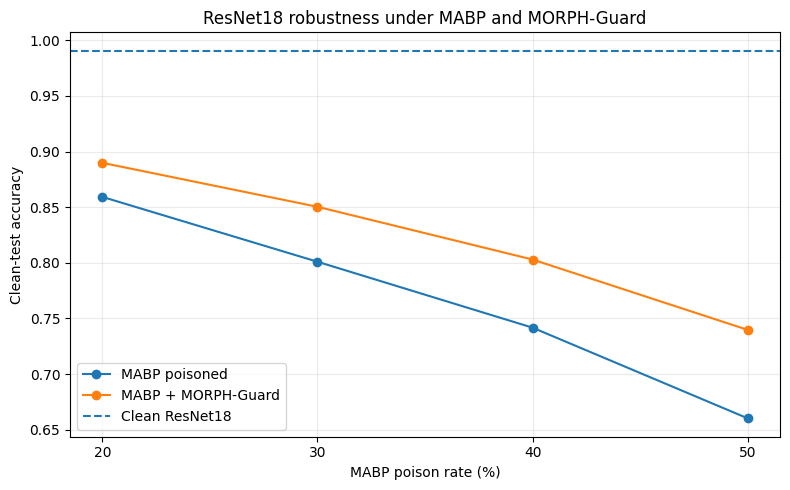

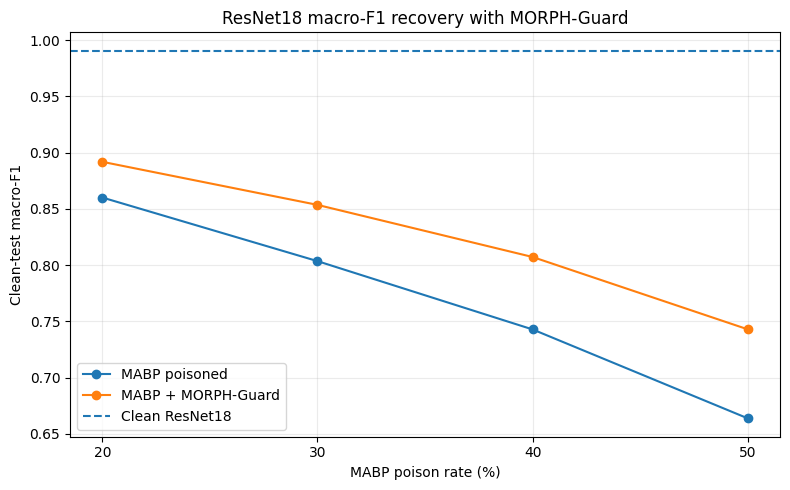

In [26]:
# 21. Paper-ready plots.

plot_df = summary_df[
    summary_df["condition"] != "Clean"
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
for condition in [
    "MABP poisoned",
    "MABP + MORPH-Guard",
]:
    part = plot_df[
        plot_df["condition"] == condition
    ].sort_values("poison_pct")

    ax.plot(
        part["poison_pct"],
        part["accuracy"],
        marker="o",
        label=condition,
    )

ax.axhline(
    clean_acc,
    linestyle="--",
    linewidth=1.5,
    label="Clean ResNet18",
)
ax.set_xlabel("MABP poison rate (%)")
ax.set_ylabel("Clean-test accuracy")
ax.set_title(
    "ResNet18 robustness under MABP and MORPH-Guard"
)
ax.set_xticks([20, 30, 40, 50])
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    WORKDIR / "accuracy_vs_poison_rate_seed42.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for condition in [
    "MABP poisoned",
    "MABP + MORPH-Guard",
]:
    part = plot_df[
        plot_df["condition"] == condition
    ].sort_values("poison_pct")

    ax.plot(
        part["poison_pct"],
        part["macro_f1"],
        marker="o",
        label=condition,
    )

ax.axhline(
    clean_f1,
    linestyle="--",
    linewidth=1.5,
    label="Clean ResNet18",
)
ax.set_xlabel("MABP poison rate (%)")
ax.set_ylabel("Clean-test macro-F1")
ax.set_title(
    "ResNet18 macro-F1 recovery with MORPH-Guard"
)
ax.set_xticks([20, 30, 40, 50])
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    WORKDIR / "macro_f1_vs_poison_rate_seed42.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [27]:
# 22. Final sanity checks.

assert SEED == 42
assert POISON_RATES == [
    0.20,
    0.30,
    0.40,
    0.50,
]
assert FINAL_CLASSIFIER == "ResNet18"
assert NUM_CLASSES == 9
assert classes == EXPECTED_CLASSES
assert set(np.unique(clean_train_labels)) == set(range(NUM_CLASSES))
assert len(train_paths) == len(clean_train_labels)
assert FINAL_PARAMS < 15_000_000

for rate in POISON_RATES:
    observed = attack_cache[rate]["poisoned_labels"]
    mask = attack_cache[rate]["poison_mask"]

    assert len(observed) == len(clean_train_labels)
    assert np.all(
        observed[~mask] ==
        clean_train_labels[~mask]
    )
    assert np.all(
        observed[mask] !=
        clean_train_labels[mask]
    )
    assert abs(mask.mean() - rate) < 0.005

expected_rows = (
    1 +
    2 * len(POISON_RATES)
)
assert len(summary_df) == expected_rows
assert excel_path.exists()

print("All ResNet18 multi-rate sanity checks passed.")
print("Results directory:", WORKDIR)
print("Excel workbook:", excel_path)

All ResNet18 multi-rate sanity checks passed.
Results directory: /content/morph_guard_nctcrc_resnet18_multirate_seed42
Excel workbook: /content/morph_guard_nctcrc_resnet18_multirate_seed42/MORPH_Guard_ResNet18_NCTCRC_Seed42_Results.xlsx


## Recommended paper claim from this notebook

The defensible ResNet18 result on NCT-CRC is:

> **MABP progressively degrades a standard pretrained ResNet18 when training labels are redirected toward morphologically plausible alternative tissue classes, whereas MORPH-Guard consistently recovers clean-test performance through out-of-fold temporal diagnosis, trusted morphology, reliability-adaptive DynaFuse, and candidate-constrained continuous repair.**

For the full Q1 submission, repeat the *same exact protocol* with DenseNet121 and VGG19.  
For the final journal version, multiple seeds are still recommended; seed 42 is the controlled first experiment requested here.

In [28]:
!zip -r morph_guard_nctcrc_resnet18_multirate_seed42.zip /content/morph_guard_nctcrc_resnet18_multirate_seed42


  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/ (stored 0%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/history_clean_resnet18_seed42.csv (deflated 61%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/resnet18_clean_seed42.pt (deflated 7%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/MORPH_Guard_ResNet18_NCTCRC_Seed42_Results.xlsx (deflated 8%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/50pct/ (stored 0%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/50pct/detection_ablation_50pct.csv (deflated 43%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/50pct/fusion_signals_50pct.csv (deflated 62%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/50pct/history_poisoned_resnet18_50pct.csv (deflated 57%)
  adding: content/morph_guard_nctcrc_resnet18_multirate_seed42/50pct/resnet18_poisoned_50pct_seed42.pt (deflated 7%)
  adding: content/morph_guard_nctcrc_resnet1